# 5. Бонус: ответ на метроном, MMN и P3a

Метроном 2 Гц (каждый восьмой удар — девиант) звучит во всех записях, но меток нет: в каждой записи неизвестны фаза ударов (0–0.5 с) и позиция девианта (1 из 8).

**Подход без меток.** Запись режется на 4-секундные циклы (8 ударов) и усредняется. Спектр среднего цикла делится на два подпространства:

| Подпространство | Частоты | Содержит |
| --- | --- | --- |
| сетка | кратные 2 Гц | ответ на каждый удар |
| девиант | k/4 Гц, не кратные 1 Гц | ответ, повторяющийся раз в 4 с |

Чётные и нечётные циклы — две независимые половины; если ответ есть, их формы совпадают. Случайный контроль сдвигает одну половину и повторяет весь поиск 2000 раз.

Порядок: пилот → проверка на открытых данных ERP CORE и гибридная симуляция → один подтверждающий тест.

In [1]:
import json
import sys
import warnings
from pathlib import Path

ROOT = Path.cwd().resolve().parent if Path.cwd().name == "results" else Path.cwd().resolve()
sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from joblib import Parallel, delayed

from src import config, erp_core, metronome, metronome_sim, viz
from src.dataset import load_record, scan_dataset

warnings.filterwarnings("ignore", message="Mean of empty slice")
viz.apply_style()
pd.set_option("display.precision", 3)
VALIDATION = ROOT / "results" / "validation"
FP_COLOR, OTHER_COLOR, NULL_COLOR = viz.COHORT_COLORS[config.GROUP_PTSD], viz.COHORT_COLORS[config.GROUP_CONTROL], viz.TEXT_MUTED

## 5.0 Условие бонуса

Нижняя граница 95% ДИ AUC основной модели должна быть выше 0.5.

In [2]:
p8 = json.loads((VALIDATION / "protocol8" / "metrics.json").read_text(encoding="utf-8"))
bonus_condition = pd.DataFrame(
    {name: p8[key]["auc_ptsd_vs_controls_excl_ageing"] for name, key in [("до калибровки", "p_raw"), ("после калибровки", "p")]}
).T.rename(columns={"value": "AUC", "ci_low": "нижняя граница 95% ДИ", "ci_high": "верхняя граница 95% ДИ"})
bonus_condition["условие бонуса (нижняя граница > 0.5)"] = bonus_condition["нижняя граница 95% ДИ"] > 0.5
bonus_condition

,AUC,нижняя граница 95% ДИ,верхняя граница 95% ДИ,условие бонуса (нижняя граница > 0.5)
до калибровки,0.864,0.796,0.919,True
после калибровки,0.824,0.753,0.886,True


## 5.1 Что в записях привязано к метроному

Записи покоя форматов A и B; согласие фаз двух половин записи на каждой частоте k/4 Гц (Fp1/Fp2). Без сигнала среднее около 0.

In [3]:
registry, _, subjects = scan_dataset()
registry = registry.join(subjects[["has_task_files"]], on="subject_key")
rows = metronome.analysis_records(registry, "rest")
rows["stratum"] = rows.apply(metronome.stratum, axis=1)
all_spectra = Parallel(n_jobs=-1)(delayed(metronome.record_cycle_spectra)(config.DATA_DIR / rel) for rel in rows["relpath"])

valid = np.array([s.valid(metronome.FRONTAL) for s in all_spectra])
rows = rows[valid].reset_index(drop=True)
spectra = [s for s, v in zip(all_spectra, valid) if v]
subject = pd.factorize(rows["subject_key"])[0]
print(f"записей покоя A/B: {valid.size}, в анализе: {valid.sum()}, испытуемых: {np.unique(subject).size}")
rows["stratum"].value_counts().rename("записей").to_frame().T

записей покоя A/B: 181, в анализе: 155, испытуемых: 155


stratum,somatoform,control_B_supplement,control_ageing,control_A,ptsd,control_B
записей,54,39,20,20,20,2


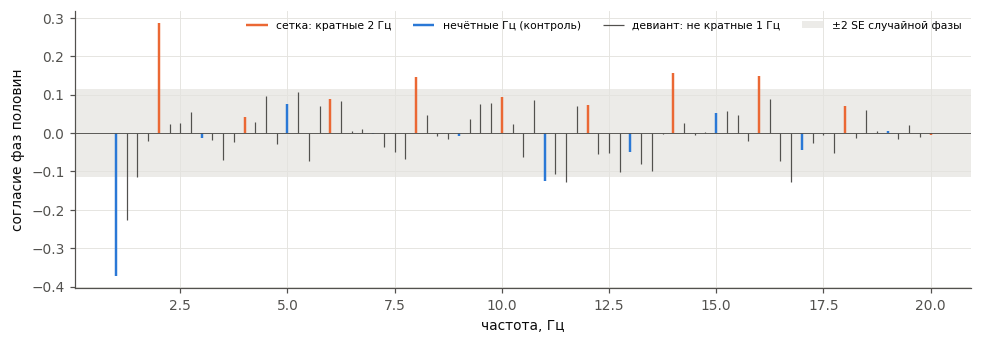

,2 Гц,4 Гц,6 Гц,8 Гц,10 Гц
согласие фаз,0.286,0.043,0.089,0.146,0.094


In [4]:
fp = np.stack([s.channel_mean(metronome.FRONTAL) for s in spectra])
a, b = fp[:, 0], fp[:, 1]
consistency = (np.real(a * b.conj()) / (np.abs(a) * np.abs(b))).mean(axis=0)
freqs = np.arange(metronome.N_BINS) * metronome.BIN_HZ
k = np.arange(metronome.N_BINS)
band = (freqs >= metronome.BAND_HZ[0]) & (freqs <= metronome.BAND_HZ[1])
chance = 2 * np.sqrt(0.5 / len(spectra))

fig, ax = plt.subplots(figsize=(9, 3.2))
for sel, color, label in [
    (band & (k % 8 == 0), FP_COLOR, "сетка: кратные 2 Гц"),
    (band & (k % 4 == 0) & (k % 8 != 0), OTHER_COLOR, "нечётные Гц (контроль)"),
    (band & (k % 4 != 0), NULL_COLOR, "девиант: не кратные 1 Гц"),
]:
    ax.vlines(freqs[sel], 0, consistency[sel], color=color, lw=1.6 if color != NULL_COLOR else 0.8, label=label)
ax.axhspan(-chance, chance, color=viz.GRID, alpha=0.7, lw=0, label="±2 SE случайной фазы")
ax.axhline(0, color=viz.TEXT_MUTED, lw=0.6)
ax.set_xlabel("частота, Гц")
ax.set_ylabel("согласие фаз половин")
ax.legend(fontsize=7, ncol=4, loc="upper right")
plt.tight_layout()
plt.show()
pd.Series(consistency[[8, 16, 24, 32, 40]], index=["2 Гц", "4 Гц", "6 Гц", "8 Гц", "10 Гц"], name="согласие фаз").to_frame().T

Согласие максимально на 2 Гц — частоте ударов — и видно ещё на части кратных 2 Гц; на нечётных герцах его нет. Отрицательное согласие на 0.75–1.5 Гц — артефакт разбиения на чётные и нечётные циклы (проверка ниже).

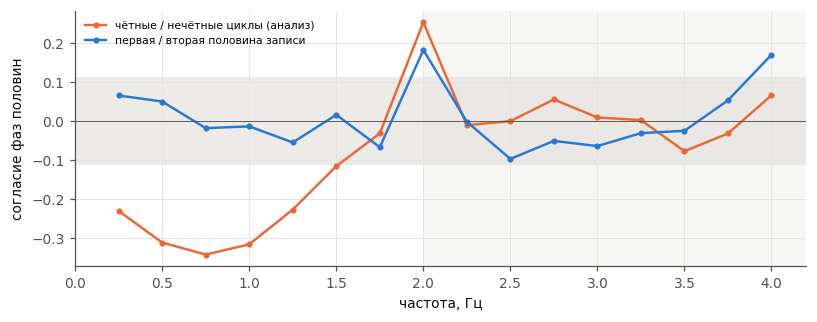

In [5]:
consistency_split = [
    r for r in Parallel(n_jobs=-1)(
        delayed(lambda rel: metronome.split_phase_consistency(load_record(config.DATA_DIR / rel)))(rel) for rel in rows["relpath"]
    ) if r is not None
]
low = (freqs > 0) & (freqs <= 4)
fig, ax = plt.subplots(figsize=(7.5, 3.0))
for name, color, label in [("interleaved", FP_COLOR, "чётные / нечётные циклы (анализ)"), ("blocks", OTHER_COLOR, "первая / вторая половина записи")]:
    mean = np.mean([r[name] for r in consistency_split], axis=0)
    ax.plot(freqs[low], mean[low], marker="o", ms=3, color=color, label=label)
ax.axhspan(-chance, chance, color=viz.GRID, alpha=0.7, lw=0)
ax.axvspan(*metronome.CONFIRM_BAND_HZ, color=viz.GRID, alpha=0.3, lw=0)
ax.axhline(0, color=viz.TEXT_MUTED, lw=0.6)
ax.set_xlabel("частота, Гц")
ax.set_ylabel("согласие фаз половин")
ax.set_xlim(0, 4.2)
ax.legend(fontsize=7)
plt.tight_layout()
plt.show()

При разбиении на первую и вторую половину записи провал исчезает, пик на 2 Гц остаётся. Случайный контроль этот провал обнуляет, поэтому проверки становятся только строже; полоса подтверждающего теста 2–8 Гц его не содержит.

## 5.2 Фильтр прибора

Порядок аппаратного ФВЧ 2 Гц оценивается по нашим спектрам: степенной фон × |H(f)|² Баттерворта n-го порядка на 0.3–6.5 Гц.

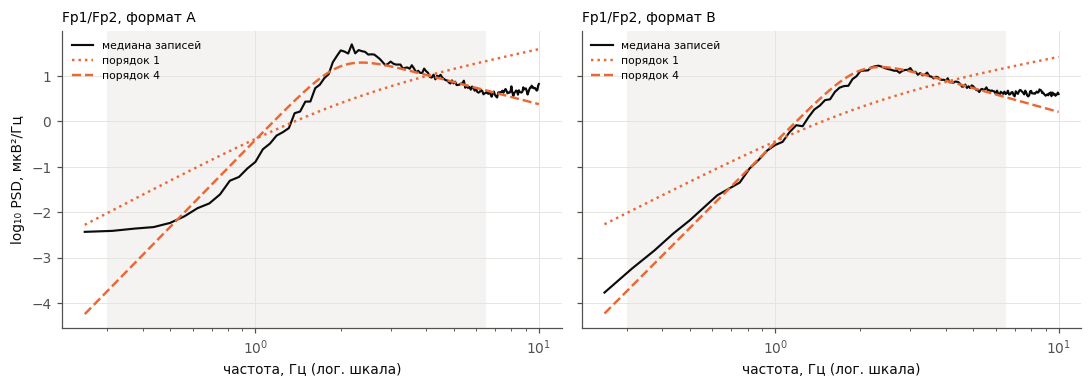

порядок фильтра,"остаток, порядок 1","остаток, порядок 2","остаток, порядок 3","остаток, порядок 4"
формат A (74 записей),33.053,17.90,8.524,5.689
формат B (81 записей),22.798,9.21,1.732,0.835


In [6]:
lowfreq = Parallel(n_jobs=-1)(delayed(metronome_sim.fp_lowfreq_spectrum)(config.DATA_DIR / rel) for rel in rows["relpath"])
lf_freqs = lowfreq[0][0]
lf_log = np.log10(np.stack([p for _, p in lowfreq]))
fits = {}
fig, axes = plt.subplots(1, 2, figsize=(10, 3.6), sharey=True)
for ax, family in zip(axes, ("A", "B")):
    m = (rows["export_family"] == family).to_numpy()
    median = np.median(lf_log[m], axis=0)
    fit = metronome_sim.highpass_order_fit(lf_freqs, median)
    fits[f"формат {family} ({m.sum()} записей)"] = fit["ssr"]
    sel = (lf_freqs >= 0.2) & (lf_freqs <= 10)
    ax.plot(lf_freqs[sel], median[sel], color="#0b0b0b", lw=1.4, label="медиана записей")
    for order, style in [(1, ":"), (4, "--")]:
        c, chi = fit.loc[order, ["c", "chi"]]
        model = c - chi * np.log10(lf_freqs[sel]) + 2 * np.log10(np.abs(erp_core.highpass_response(lf_freqs[sel], order)))
        ax.plot(lf_freqs[sel], model, style, color=FP_COLOR, label=f"порядок {order}")
    ax.axvspan(*metronome_sim.ORDER_FIT_BAND_HZ, color=viz.GRID, alpha=0.4, lw=0)
    ax.set_xscale("log")
    ax.set_xlabel("частота, Гц (лог. шкала)")
    ax.set_title(f"Fp1/Fp2, формат {family}", loc="left", fontsize=9)
    ax.legend(fontsize=7)
axes[0].set_ylabel("log₁₀ PSD, мкВ²/Гц")
plt.tight_layout()
plt.show()
pd.DataFrame(fits).rename_axis("порядок фильтра").T.rename(columns=lambda n: f"остаток, порядок {n}")

Лучше всего подходит 4-й порядок (спад 24 дБ на октаву). Дальше эмулируется причинный фильтр 4-го порядка на 2 Гц.

## 5.3 MMN из открытых данных в наших условиях

ERP CORE (Kappenman et al., 2021; CC BY-SA 4.0): 40 взрослых, пассивный oddball, девиант тише на 10 дБ. Сначала — воспроизводится ли опубликованная MMN, затем — как она выглядит на Fp1/Fp2 после фильтра прибора.

In [7]:
if not any(erp_core.DEFAULT_DIR.glob(f"*{erp_core.ERPSET_SUFFIX}")):
    erp_core.download_erpsets()
erp_metrics, erp_curves = erp_core.summary(erp_core.load_all())
erp_table = pd.DataFrame(erp_metrics).T[
    ["mmn_window_mean_uv", "mmn_window_share_negative", "difference_extremum_uv", "difference_extremum_latency_s", "difference_rms_0_600ms_uv"]
].rename(columns={
    "mmn_window_mean_uv": "среднее 125–225 мс, мкВ",
    "mmn_window_share_negative": "доля участников < 0",
    "difference_extremum_uv": "экстремум 50–400 мс, мкВ",
    "difference_extremum_latency_s": "латентность экстремума, с",
    "difference_rms_0_600ms_uv": "СКЗ 0–600 мс, мкВ",
})
erp_table

,"среднее 125–225 мс, мкВ",доля участников < 0,"экстремум 50–400 мс, мкВ","латентность экстремума, с","СКЗ 0–600 мс, мкВ"
FCz,-1.848,0.950,-2.819,0.191,0.968
Fp,-1.179,0.950,-1.719,0.188,0.590
Fp HP1,-0.647,0.925,-1.061,0.180,0.388
Fp HP2,-0.391,0.875,1.217,0.250,0.401
Fp HP4,-0.046,0.450,1.240,0.242,0.407
C5/C6 HP4,-0.143,0.625,1.114,0.246,0.434
O1/O2 HP4,-0.000,0.400,0.328,0.246,0.125


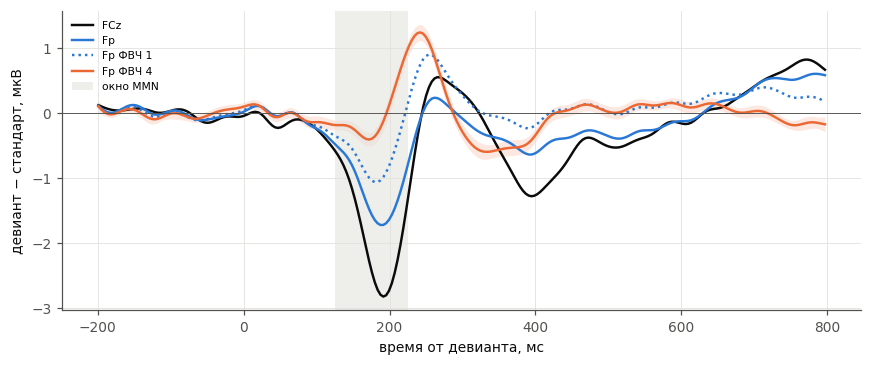

In [8]:
fig, ax = plt.subplots(figsize=(8, 3.4))
for view, color, style in [("FCz", "#0b0b0b", "-"), ("Fp", OTHER_COLOR, "-"), ("Fp HP1", OTHER_COLOR, ":"), ("Fp HP4", FP_COLOR, "-")]:
    d = erp_curves[(erp_curves["view"] == view) & (erp_curves["wave"] == "difference")]
    ax.plot(d["time_s"] * 1000, d["mean_uv"], style, color=color, label=view.replace("HP", "ФВЧ "))
    if view == "Fp HP4":
        ax.fill_between(d["time_s"] * 1000, d["mean_uv"] - d["sem_uv"], d["mean_uv"] + d["sem_uv"], color=color, alpha=0.15, lw=0)
ax.axvspan(125, 225, color=viz.GRID, alpha=0.6, lw=0, label="окно MMN")
ax.axhline(0, color=viz.TEXT_MUTED, lw=0.6)
ax.set_xlabel("время от девианта, мс")
ax.set_ylabel("девиант − стандарт, мкВ")
ax.legend(fontsize=7)
plt.tight_layout()
plt.show()

Опубликованная MMN на FCz воспроизводится (−1.85 мкВ). После фильтра прибора энергия ответа на Fp почти сохраняется, но форма становится «−/+/−» с положительным пиком около 250 мс. Поэтому нужны энергетические статистики, а положительность около 250 мс нельзя без оговорок называть P3a.

## 5.4 Ответ на удары

Проверка 1 — корреляция половин в подпространстве сетки на 2–10 Гц; контроль — нечётные 1–9 Гц. Расчёт подтверждающего запуска повторяется и сверяется с сохранённым.

In [9]:
w = metronome.half_waveforms(spectra, deviant_band_hz=metronome.CONFIRM_BAND_HZ)
out = metronome.recover(w)
observed = metronome.group_statistics(out, subject)
null, null_curves = metronome.random_control(w, subject, metronome.N_SURROGATES, config.RANDOM_STATE)
p = {key: metronome.p_value(observed[key], null[key], metronome.TEST_DIRECTION[key]) for key in observed}

saved = json.loads((VALIDATION / "metronome_confirm" / "metrics.json").read_text(encoding="utf-8"))["rest"]
assert all(abs(round(observed[key], 5) - saved["observed"][key]) < 1e-9 for key in observed), "observed differs from saved run"
assert all(abs(round(p[key], 4) - saved["p"][key]) < 1e-9 for key in p), "p differs from saved run"
print("совпадает с сохранённым подтверждающим запуском")

совпадает с сохранённым подтверждающим запуском


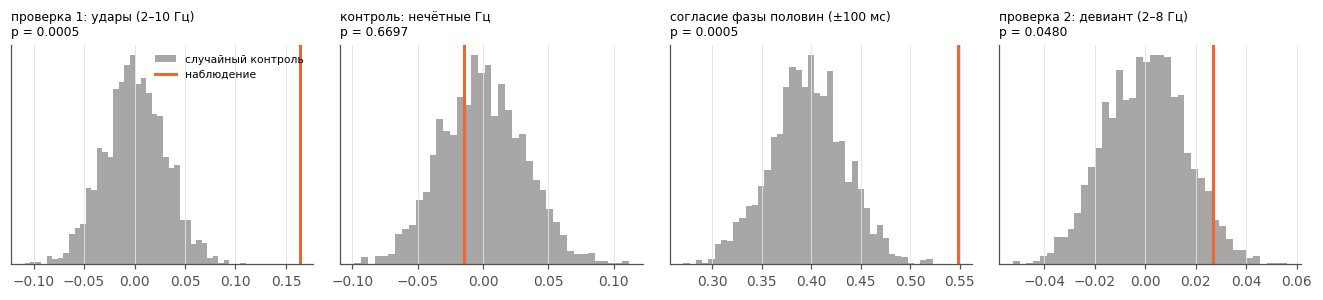

In [10]:
TITLES = {
    "grid_r": "проверка 1: удары (2–10 Гц)",
    "odd_r": "контроль: нечётные Гц",
    "onset_agreement": "согласие фазы половин (±100 мс)",
    "deviant_r": "проверка 2: девиант (2–8 Гц)",
}
fig, axes = plt.subplots(1, 4, figsize=(12, 2.8))
for ax, (key, title) in zip(axes, TITLES.items()):
    ax.hist(null[key], bins=40, color=NULL_COLOR, alpha=0.5, label="случайный контроль")
    ax.axvline(observed[key], color=FP_COLOR, lw=2, label="наблюдение")
    ax.set_title(f"{title}\np = {p[key]:.4f}", loc="left", fontsize=8)
    ax.set_yticks([])
axes[0].legend(fontsize=7)
plt.tight_layout()
plt.show()

**Топография и форма ответа на удар.** Каждая половина выровнена по фазе, найденной на другой половине, поэтому форма не навязана поиском. Ось времени условна: начало удара = минимум N1 − 100 мс.

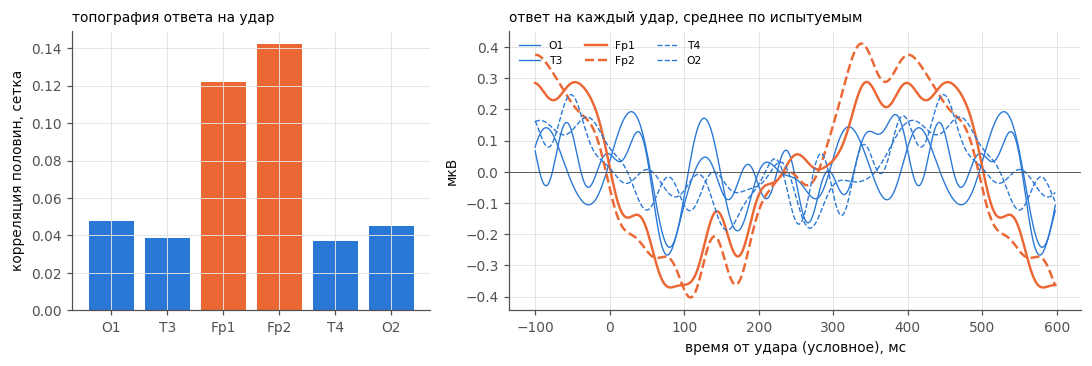

,записей,корреляция половин,p
O1,147.0,0.048,0.022
T3,121.0,0.039,0.056
Fp1,155.0,0.122,0.002
Fp2,155.0,0.142,0.002
T4,132.0,0.037,0.072
O2,138.0,0.045,0.040


In [11]:
channels = pd.DataFrame({
    ch: {"записей": v["n_records"], "корреляция половин": v["grid_r"]["observed"], "p": v["grid_r"]["p"]}
    for ch, v in saved["channels"].items()
}).T
curves = pd.read_csv(VALIDATION / "metronome_confirm" / "curves_rest.csv")

fig, axes = plt.subplots(1, 2, figsize=(10, 3.4), gridspec_kw={"width_ratios": [1, 1.6]})
colors = [FP_COLOR if ch in metronome.FRONTAL else OTHER_COLOR for ch in channels.index]
axes[0].bar(channels.index, channels["корреляция половин"], color=colors)
axes[0].set_ylabel("корреляция половин, сетка")
axes[0].set_title("топография ответа на удар", loc="left", fontsize=9)
for ch in config.CHANNELS:
    d = curves[(curves["kind"] == "grid") & (curves["channel"] == ch)]
    color = FP_COLOR if ch in metronome.FRONTAL else OTHER_COLOR
    axes[1].plot(d["time_s"] * 1000, d["mean_uv"], color=color, lw=1.6 if ch in metronome.FRONTAL else 0.9,
                 ls="-" if ch in ("Fp1", "O1", "T3") else "--", label=ch)
axes[1].axhline(0, color=viz.TEXT_MUTED, lw=0.6)
axes[1].set_xlabel("время от удара (условное), мс")
axes[1].set_ylabel("мкВ")
axes[1].set_title("ответ на каждый удар, среднее по испытуемым", loc="left", fontsize=9)
axes[1].legend(fontsize=7, ncol=3)
plt.tight_layout()
plt.show()
channels

**Покой против таблиц Шульте** (пилот):

In [12]:
pilot = json.loads((VALIDATION / "metronome_pilot" / "metrics.json").read_text(encoding="utf-8"))
pd.DataFrame({
    condition: {
        "записей": pilot[condition]["n_records"],
        "испытуемых": pilot[condition]["n_subjects"],
        "проверка 1 (удары)": pilot[condition]["observed"]["grid_r"],
        "p (удары)": pilot[condition]["p"]["grid_r"],
        "контроль нечётных Гц, p": pilot[condition]["p"]["odd_r"],
        "проверка 2 (девиант, 1–20 Гц), p": pilot[condition]["p"]["deviant_r"],
    }
    for condition in ("rest", "task")
}).rename(columns={"rest": "покой", "task": "тест Шульте"}).T

,записей,испытуемых,проверка 1 (удары),p (удары),"контроль нечётных Гц, p","проверка 2 (девиант, 1–20 Гц), p"
покой,155.0,155.0,0.163,5.000e-04,0.670,0.052
тест Шульте,314.0,106.0,0.024,1.609e-01,0.664,0.826


В покое ответ на удары надёжен (p = 0.0005), специфичен к частотам сетки и фронтален (Fp1/Fp2 в 3 раза выше остальных каналов — типично для слухового N1 при ушном референте). Во время таблиц Шульте не обнаружен: внимание к зрительной задаче и артефакты глаз.

## 5.5 Чувствительность метода

В реальные записи покоя вставлялся ответ ERP CORE известного размера a в известные моменты, и прогонялся тот же конвейер (20 повторов на размер). Шум — «плюс-минус» (Schimmel, 1967): настоящий отклик на метроном в нём сокращается. Здесь читаются сохранённые результаты.

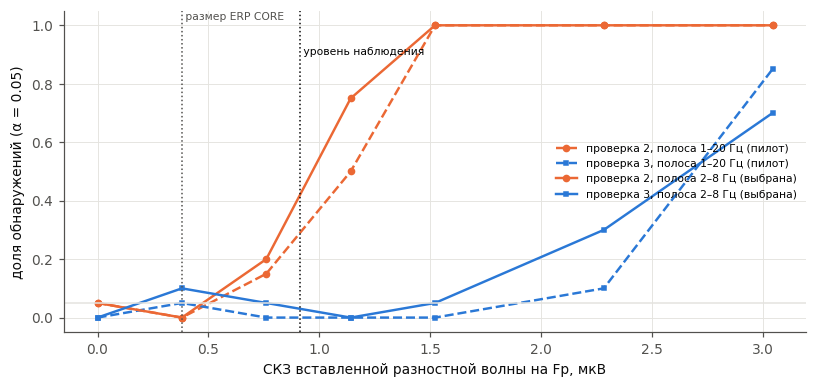

СКЗ, мкВ  мощность проверки 2  \
вариант                 amplitude                                  
полоса 2–8 Гц (выбрана) 0.0           0.000                 0.05   
                        1.0           0.380                 0.00   
                        2.0           0.761                 0.20   
                        3.0           1.141                 0.75   
                        4.0           1.521                 1.00   
                        6.0           2.282                 1.00   
                        8.0           3.042                 1.00   
полоса 1–20 Гц (пилот)  0.0           0.000                 0.05   
                        1.0           0.380                 0.00   
                        2.0           0.761                 0.15   
                        3.0           1.141                 0.50   
                        4.0           1.521                 1.00   
                        6.0           2.282                 1.00   
                        8.0           3.042                 1.00   

                                   мощность проверки 3  фаза ±50 мс  \
вариант                 amplitude                                     
полоса 2–8 Гц (выбрана) 0.0                       0.00        0.299   
                        1.0                       0.10        0.301   
                        2.0                       0.05        0.305   
                        3.0                       0.00        0.291   
                        4.0                       0.05        0.293   
                        6.0                       0.30        0.279   
                        8.0                       0.70        0.266   
полоса 1–20 Гц (пилот)  0.0                       0.00        0.299   
                        1.0                       0.05        0.301   
                        2.0                       0.00        0.305   
                        3.0                       0.00        0.291   
                        4.0                       0.00        0.293   
                        6.0                       0.10        0.279   
                        8.0                       0.85        0.266   

                                   позиция девианта найдена  
вариант                 amplitude                            
полоса 2–8 Гц (выбрана) 0.0                           0.057  
                        1.0                           0.057  
                        2.0                           0.075  
                        3.0                           0.092  
                        4.0                           0.132  
                        6.0                           0.225  
                        8.0                           0.307  
полоса 1–20 Гц (пилот)  0.0                           0.055  
                        1.0                           0.058  
                        2.0                           0.073  
                        3.0                           0.093  
                        4.0                           0.121  
                        6.0                           0.206  
                        8.0                           0.291

In [13]:
power = pd.read_csv(VALIDATION / "metronome_validation" / "hybrid_power.csv")
labels = {"pilot_1_20Hz": "полоса 1–20 Гц (пилот)", "mmn_2_8Hz": "полоса 2–8 Гц (выбрана)"}
confirm_band = power[power["variant"] == "mmn_2_8Hz"].sort_values("amplitude")
observed_rms = np.interp(observed["deviant_r"], confirm_band["deviant_r"], confirm_band["difference_rms_uv"])

fig, ax = plt.subplots(figsize=(7.5, 3.6))
for variant, style in [("pilot_1_20Hz", "--"), ("mmn_2_8Hz", "-")]:
    d = power[power["variant"] == variant].sort_values("amplitude")
    ax.plot(d["difference_rms_uv"], d["test2_power"], style, marker="o", ms=4, color=FP_COLOR, label=f"проверка 2, {labels[variant]}")
    ax.plot(d["difference_rms_uv"], d["test3_power"], style, marker="s", ms=3, color=OTHER_COLOR, label=f"проверка 3, {labels[variant]}")
erp_rms = confirm_band.loc[confirm_band["amplitude"] == 1.0, "difference_rms_uv"].item()
ax.axvline(erp_rms, color=viz.TEXT_MUTED, ls=":", lw=1)
ax.text(erp_rms, 1.02, " размер ERP CORE", fontsize=7, color=viz.TEXT_MUTED)
ax.axvline(observed_rms, color="#0b0b0b", ls=":", lw=1)
ax.text(observed_rms, 0.9, " уровень наблюдения", fontsize=7)
ax.axhline(0.05, color=viz.GRID, lw=1)
ax.set_xlabel("СКЗ вставленной разностной волны на Fp, мкВ")
ax.set_ylabel("доля обнаружений (α = 0.05)")
ax.legend(fontsize=7, loc="center right")
plt.tight_layout()
plt.show()

power.assign(вариант=power["variant"].map(labels)).set_index(["вариант", "amplitude"])[
    ["difference_rms_uv", "test2_power", "test3_power", "phase_within_50ms_of_bias", "deviant_found"]
].rename(columns={
    "difference_rms_uv": "СКЗ, мкВ",
    "test2_power": "мощность проверки 2",
    "test3_power": "мощность проверки 3",
    "phase_within_50ms_of_bias": "фаза ±50 мс",
    "deviant_found": "позиция девианта найдена",
})

- Без сигнала ложных срабатываний ~5%, как и должно быть.
- Проверка 2 находит ответ со СКЗ ≥ 1.1–1.5 мкВ на Fp; ответ размера ERP CORE (0.38 мкВ) — нет.
- Разметку отдельной записи восстановить нельзя, поэтому извлечённая кривая (проверка 3) срабатывает только на очень больших ответах.

## 5.6 Подтверждающий тест девианта

Один запуск: полоса 2–8 Гц, 2000 случайных контролей, порог 0.025 (вторая проверка на тех же записях).

In [14]:
confirm_table = pd.DataFrame({
    "наблюдение": {key: observed[key] for key in ("deviant_r", "curve_energy")},
    "среднее контроля": {key: null[key].mean() for key in ("deviant_r", "curve_energy")},
    "95-й перцентиль контроля": {key: np.quantile(null[key], 0.95) for key in ("deviant_r", "curve_energy")},
    "p": {key: p[key] for key in ("deviant_r", "curve_energy")},
}).rename(index={"deviant_r": "проверка 2: корреляция половин", "curve_energy": "проверка 3: энергия кривой"})
confirm_table["значимо при 0.025"] = confirm_table["p"] < metronome.CONFIRM_ALPHA
print(f"уровень наблюдения по гибридной калибровке: СКЗ ≈ {observed_rms:.2f} мкВ на Fp")
confirm_table

уровень наблюдения по гибридной калибровке: СКЗ ≈ 0.91 мкВ на Fp


,наблюдение,среднее контроля,95-й перцентиль контроля,p,значимо при 0.025
проверка 2: корреляция половин,0.027,1.527e-04,0.026,0.048,False
проверка 3: энергия кривой,0.034,4.331e-02,0.099,0.549,False


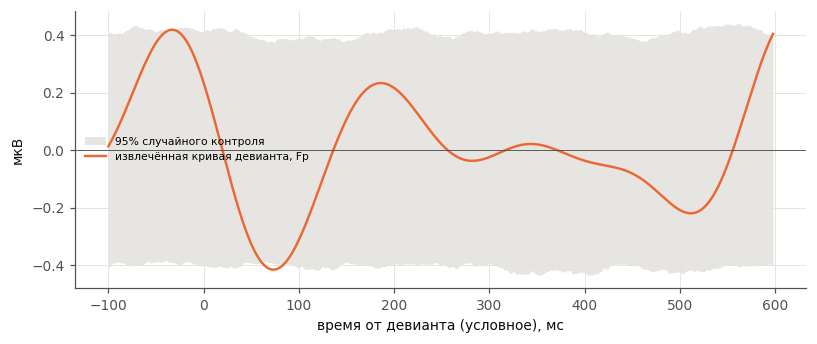

In [15]:
d = curves[(curves["kind"] == "deviant") & (curves["channel"] == "Fp")]
fig, ax = plt.subplots(figsize=(7.5, 3.2))
ax.fill_between(d["time_s"] * 1000, d["null_q025_uv"], d["null_q975_uv"], color=viz.GRID, alpha=0.9, lw=0, label="95% случайного контроля")
ax.plot(d["time_s"] * 1000, d["mean_uv"], color=FP_COLOR, label="извлечённая кривая девианта, Fp")
ax.axhline(0, color=viz.TEXT_MUTED, lw=0.6)
ax.set_xlabel("время от девианта (условное), мс")
ax.set_ylabel("мкВ")
ax.legend(fontsize=7)
plt.tight_layout()
plt.show()

Ответ на девиант не подтверждён (p = 0.048 при пороге 0.025); извлечённая кривая внутри полосы случайного контроля. Ответ со СКЗ ≥ 1.5 мкВ исключён; ответ размера ERP CORE метод обнаружить не может.

## 5.7 Итог

| Утверждение | Статус |
| --- | --- |
| Условие бонуса (нижняя граница ДИ AUC > 0.5) | выполнено |
| Слуховой ответ на удары метронома найден без меток | **показано** (p = 0.0005, контроль нечётных частот — нет эффекта) |
| Ответ фронтальный | показано |
| Ответ во время таблиц Шульте | не обнаружен |
| Метод проверен на открытых данных (ERP CORE, гибридная симуляция) | сделано |
| Фильтр прибора — 4-й порядок, меняет форму MMN | оценено |
| Ответ на девиант (MMN/P3a) | **не показан**, ответ ≥ 1.5 мкВ исключён |

Ограничения: неизвестны фазовая характеристика фильтра, физическое отличие девианта и то, звучал ли метроном во всех записях. Ответ на удары в модель не входит.